# 01 — Simulate one microtubule, fit it, verify the math

This notebook exercises the **math core** of `kapoorlabs_mtrack`:

1. Render a synthetic microtubule image from known truth parameters
2. Add Poisson + read noise so it looks like real fluorescence data
3. Fit the spline-Gaussian model with Levenberg–Marquardt (both analytic and hybrid Jacobian modes)
4. Compare the analytic Jacobian against central differences, parameter by parameter

Everything is direct imports from the installed package — no helper scripts.

In [1]:
# Make the in-tree package importable without `pip install -e .`.
import sys, pathlib
_pkg_src = pathlib.Path.cwd().parent / 'src'
if _pkg_src.is_dir() and str(_pkg_src) not in sys.path:
    sys.path.insert(0, str(_pkg_src))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from kapoorlabs_mtrack.simulate import render_curve_image, add_shot_noise
from kapoorlabs_mtrack.fit import fit_endpoints
from kapoorlabs_mtrack.models import val, jac, walk_curve
from kapoorlabs_mtrack.verify import check_jacobian

plt.rcParams['figure.dpi'] = 110

## 1 · Truth parameters

Microscope PSF (`sigma`) is fixed in `b = 1/sigma²`. The model parameter vector `a` has 9 free entries — see the README table.


In [2]:
sigma = np.array([1.6, 1.6])
b = 1.0 / (sigma * sigma)

truth = np.array([
    10.0,   # start_x
    14.0,   # start_y
    52.0,   # end_x
    34.0,   # end_y
    0.7,    # ds (curve step length)
    0.008,  # curvature
    0.0,    # inflection
    120.0,  # amplitude
    8.0,    # background
])

labels = ['start_x','start_y','end_x','end_y','ds','curvature','inflection','amplitude','background']
pd.DataFrame({'param': labels, 'truth': truth})

,param,truth
0,start_x,10.000
1,start_y,14.000
2,end_x,52.000
3,end_y,34.000
4,ds,0.700
5,curvature,0.008
6,inflection,0.000
7,amplitude,120.000
8,background,8.000


## 2 · Render + noise


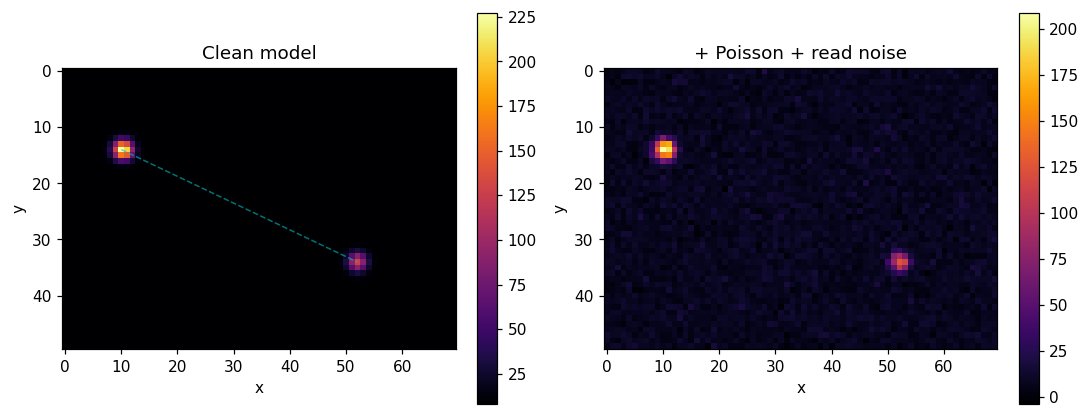

In [3]:
shape = (50, 70)
rng = np.random.default_rng(0)
clean = render_curve_image(truth, b, shape)
noisy = add_shot_noise(clean, read_noise_sigma=2.0, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im0 = axes[0].imshow(clean, cmap='inferno')
axes[0].set_title('Clean model')
axes[0].plot([truth[0], truth[2]], [truth[1], truth[3]], 'c--', lw=1, alpha=0.6)
plt.colorbar(im0, ax=axes[0], fraction=0.045)
im1 = axes[1].imshow(noisy, cmap='inferno')
axes[1].set_title('+ Poisson + read noise')
plt.colorbar(im1, ax=axes[1], fraction=0.045)
for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## 3 · Fit with the analytic-only Jacobian (Java-faithful, fast)

The endpoint columns of the analytic Jacobian are an approximation — they drop the swept-curve coupling. Expect ~1–2 px endpoint bias.


In [4]:
seed = truth.copy()
seed[0:2] += [0.9, -0.7]
seed[2:4] += [-0.8, 1.0]
seed[5] = seed[6] = 0.0
bg = float(np.median(noisy))
seed[8] = bg
seed[7] = max(1.0, (noisy.max() - bg) / 5.0)

weights = 1.0 / np.sqrt(np.clip(noisy, 1.0, None))

fit_an = fit_endpoints(noisy, seed, b, weights=weights, jac_mode='analytic')
fit_hy = fit_endpoints(noisy, seed, b, weights=weights, jac_mode='hybrid')

df = pd.DataFrame({
    'param': labels,
    'truth': truth,
    'seed':  seed,
    'analytic': fit_an.a,
    'hybrid':   fit_hy.a,
}).round(3)
df

,param,truth,seed,analytic,hybrid
0,start_x,10.000,10.900,6.369,2.185
1,start_y,14.000,13.300,34.604,6.333
2,end_x,52.000,51.200,52.813,48.104
3,end_y,34.000,35.000,17.625,32.143
4,ds,0.700,0.700,4.384,3.257
5,curvature,0.008,0.000,0.052,-0.016
6,inflection,0.000,0.000,-0.001,0.000
7,amplitude,120.000,40.111,0.429,1.924
8,background,8.000,8.014,5.809,5.746


In [5]:
start_err_an = np.linalg.norm(fit_an.start - truth[0:2])
end_err_an   = np.linalg.norm(fit_an.end   - truth[2:4])
start_err_hy = np.linalg.norm(fit_hy.start - truth[0:2])
end_err_hy   = np.linalg.norm(fit_hy.end   - truth[2:4])
pd.DataFrame({
    'mode':  ['analytic', 'hybrid'],
    'start_err_px': [start_err_an, start_err_hy],
    'end_err_px':   [end_err_an,   end_err_hy],
    'nfev': [fit_an.nfev, fit_hy.nfev],
    'final_cost': [fit_an.cost, fit_hy.cost],
}).round(3)

,mode,start_err_px,end_err_px,nfev,final_cost
0,analytic,20.922,16.395,24,5579.013
1,hybrid,10.948,4.316,23,5544.238


## 4 · Overlay the recovered curves on the noisy image


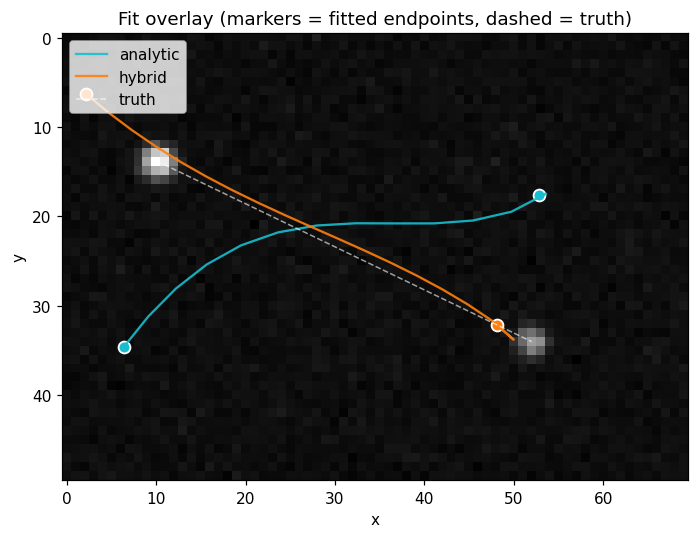

In [6]:
def curve_for(a):
    pts = walk_curve(a)
    return np.vstack([a[0:2][None,:], pts, a[2:4][None,:]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(noisy, cmap='gray')
for fit, color, name in [(fit_an, 'tab:cyan', 'analytic'),
                          (fit_hy, 'tab:orange', 'hybrid')]:
    pts = curve_for(fit.a)
    ax.plot(pts[:, 0], pts[:, 1], '-', lw=1.5, color=color, alpha=0.9, label=name)
    ax.scatter(*fit.start, c=color, s=60, edgecolor='white', linewidth=1.2)
    ax.scatter(*fit.end,   c=color, s=60, edgecolor='white', linewidth=1.2)
tpts = curve_for(truth)
ax.plot(tpts[:, 0], tpts[:, 1], 'w--', lw=1, alpha=0.6, label='truth')
ax.set_title('Fit overlay (markers = fitted endpoints, dashed = truth)')
ax.legend(loc='upper left')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## 5 · Gradient verification table

For shape parameters (ds, curvature, inflection, amp, bg) analytic ≈ numeric to round-off. Endpoint columns disagree on purpose — the Java port keeps the fast approximation.

In [7]:
x = np.array([[12.0, 15.0], [25.0, 22.0], [45.0, 31.0]])
reports = check_jacobian(val, jac, x, truth, b, eps=1e-5)
df = pd.DataFrame([
    {'param': labels[r.param_index],
     'analytic_norm': r.analytic_norm,
     'numeric_norm': r.numeric_norm,
     'abs_err': r.max_abs_err,
     'rel_err': r.max_rel_err}
    for r in reports
])
df.style.format({'analytic_norm': '{:.3e}', 'numeric_norm': '{:.3e}',
                  'abs_err': '{:.2e}', 'rel_err': '{:.2e}'})

,param,analytic_norm,numeric_norm,abs_err,rel_err
0,start_x,2.659e+01,7.265e+01,4.61e+01,6.34e-01
1,start_y,1.330e+01,4.448e+01,3.12e+01,7.01e-01
2,end_x,9.497e-08,3.311e-01,3.31e-01,1.00e+00
3,end_y,4.070e-08,4.076e-01,4.08e-01,1.00e+00
4,ds,4.967e+01,4.967e+01,5.02e-10,1.01e-11
5,curvature,7.191e+02,7.191e+02,8.20e-05,1.14e-07
6,inflection,5.177e+04,1.922e+07,1.76e+07,1.00e+00
7,amplitude,5.151e-01,5.151e-01,4.88e-10,3.86e-01
8,background,1.732e+00,1.732e+00,3.17e-10,3.17e-10
